In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [3]:
import pandas as pd
import zipfile
import io

# Assuming 'archive (2).zip' is the uploaded zip file containing the CSV
zip_file_name = 'archive (2).zip'
csv_file_name = 'abcnews-date-text.csv'

# Extract the zip file
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    z.extractall()

# Now read the CSV file
data = pd.read_csv(csv_file_name)

data.head()

,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers


In [4]:
text = " ".join(data['headline_text'].astype(str))

Word Cloud


In [5]:
!pip install wordcloud

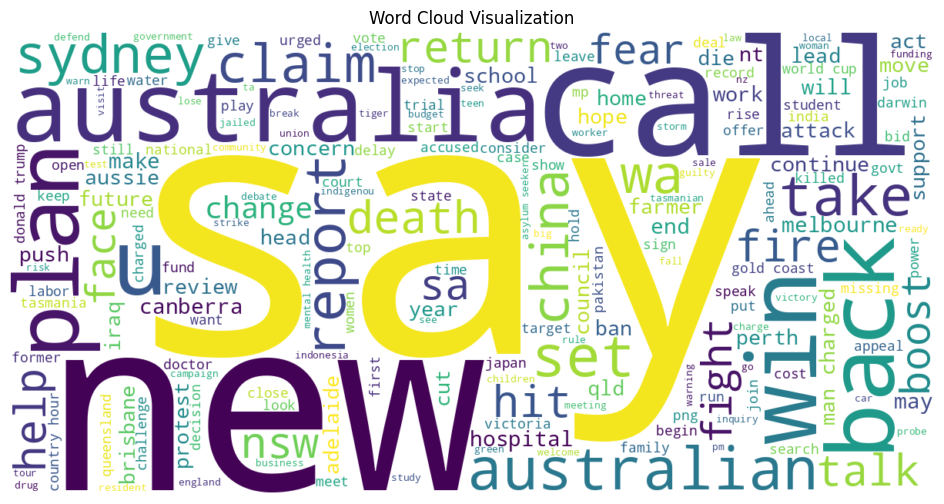

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Visualization")
plt.show()

Word Tree

In [7]:
!pip install wordcloud wordtree

In [8]:
from IPython.display import HTML

HTML("""
<script type="text/javascript" src="https://www.gstatic.com/charts/loader.js"></script>
<div id="wordtree_basic" style="width: 900px; height: 500px;"></div>

<script>
google.charts.load('current', {packages:['wordtree']});
google.charts.setOnLoadCallback(drawChart);

function drawChart() {
var data = google.visualization.arrayToDataTable(
[['Phrases'],
['government plans new infrastructure policy'],
['government announces new education reform'],
['government introduces health policy'],
['technology companies invest in artificial intelligence'],
['artificial intelligence transforms modern technology']]
);

var options = {
wordtree: {
format: 'implicit',
word: 'government'
}
};

var chart = new google.visualization.WordTree(document.getElementById('wordtree_basic'));
chart.draw(data, options);
}
</script>
""")

Text Arc

In [9]:
!pip install networkx

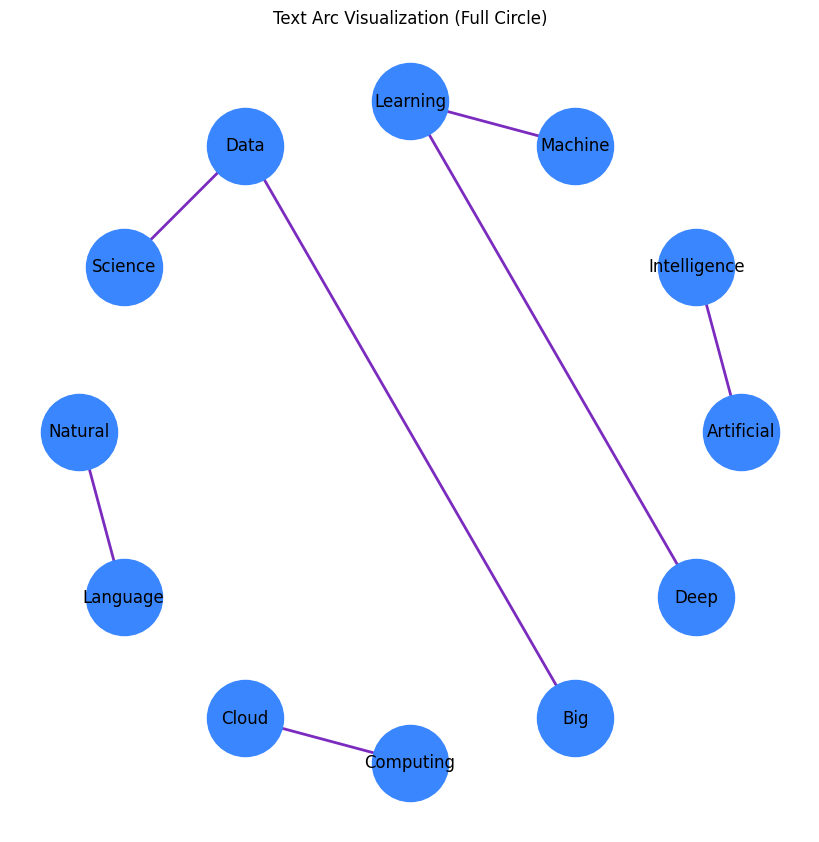

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

edges = [
("Artificial","Intelligence"),
("Machine","Learning"),
("Data","Science"),
("Natural","Language"),
("Cloud","Computing"),
("Big","Data"),
("Deep","Learning")
]

G.add_edges_from(edges)

pos = nx.circular_layout(G)

plt.figure(figsize=(8,8))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="#3A86FF",
    font_size=12,
    edge_color="#7B2CBF",
    width=2
)

plt.title("Text Arc Visualization (Full Circle)")
plt.show()

Arc Diagram

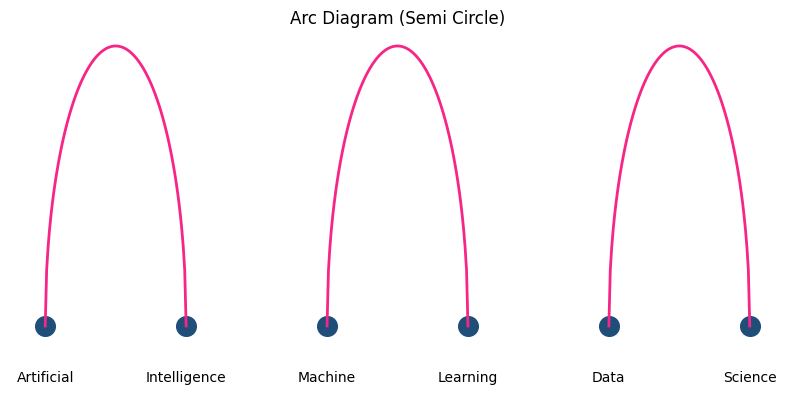

In [11]:
import numpy as np

nodes = ["Artificial","Intelligence","Machine","Learning","Data","Science"]
edges = [(0,1),(2,3),(4,5)]

plt.figure(figsize=(10,4))

for edge in edges:
    x1, x2 = edge
    xs = np.linspace(x1, x2, 100)
    ys = np.sqrt((x2-x1)**2/4 - (xs-(x1+x2)/2)**2)
    plt.plot(xs, ys, color="#F72585", linewidth=2)

plt.scatter(range(len(nodes)), [0]*len(nodes), color="#1F4E79", s=200)

for i,node in enumerate(nodes):
    plt.text(i,-0.1,node,ha='center')

plt.axis("off")
plt.title("Arc Diagram (Semi Circle)")
plt.show()

Literature Fingerprinting

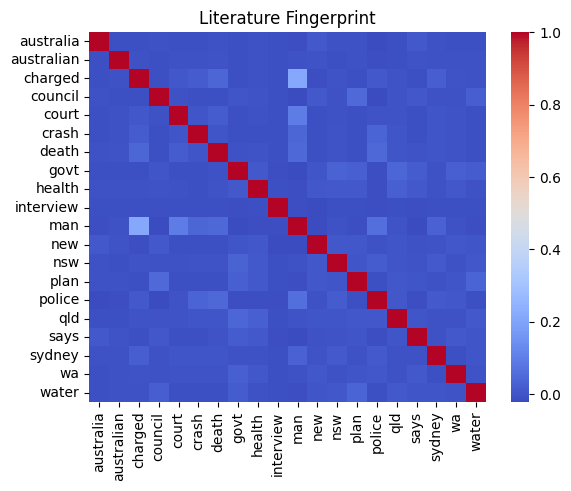

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

vectorizer = CountVectorizer(stop_words="english", max_features=20)

X = vectorizer.fit_transform(data['headline_text'])

freq = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

sns.heatmap(freq.corr(), cmap="coolwarm")
plt.title("Literature Fingerprint")
plt.show()